In [5]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [16]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [17]:
from model.metrics import MSE, evaluate_linear_regression
from model.gradients import MSE_grad
from model.utils import *
import matplotlib.pyplot as plt

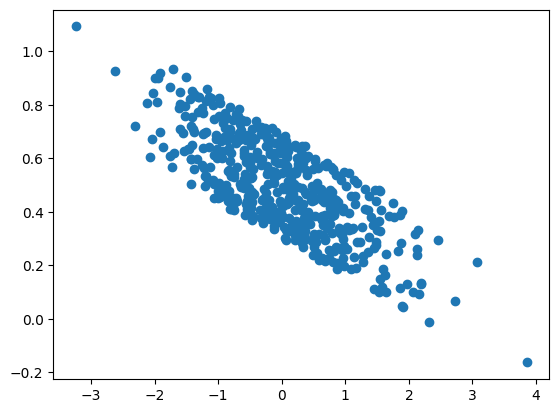

In [36]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

In [54]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_B.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (1600, 2), y size : (1600,)


50. Training loss: 0.6333011463329974, Val loss:0.605763731465133
100. Training loss: 0.560944176029853, Val loss:0.5347780170370382
150. Training loss: 0.5011005997675119, Val loss:0.47616215994096633
200. Training loss: 0.4516056474010014, Val loss:0.4277683253433776
250. Training loss: 0.41066917554133203, Val loss:0.3878209660417229
300. Training loss: 0.37681081233745717, Val loss:0.354852342304647
350. Training loss: 0.3488063343172151, Val loss:0.32764920718227697
400. Training loss: 0.32564332924740713, Val loss:0.3052087237083346
450. Training loss: 0.30648453628529515, Val loss:0.28670201534712025
500. Training loss: 0.2906375335120469, Val loss:0.27144402793270805


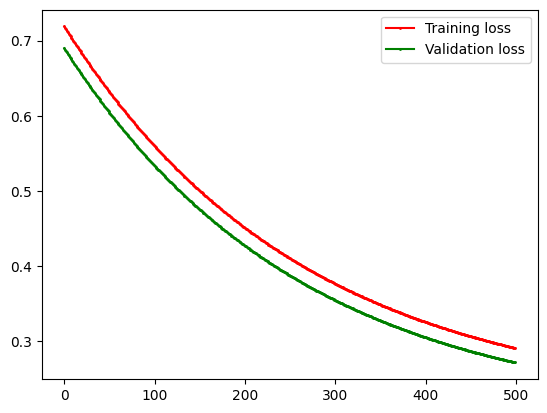

In [60]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient. 
loss_fn = MSE
grad_fn = MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.001,n_iteration =500,val_ratio=0.2)

In [61]:
# Get the Prediction
y_val_pred = model.predict(X_val)

In [62]:
# Evaluation 
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

=== Linear Regression Evaluation ===
MSE       : 0.2687
MAE       : 0.4404
RMSE      : 0.5184
R-squared : -0.2011


{'MSE': 0.26870180820833145,
 'MAE': 0.4403913458737695,
 'RMSE': np.float64(0.5183645514580751),
 'R-squared': -0.20107148952663834}

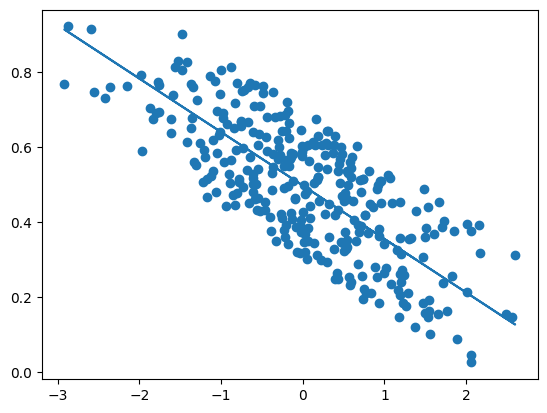

In [15]:
# Plot
plt.scatter(X_val[:,1],y_val)
plt.plot(X_val[:,1],y_val_pred)
plt.show()